# Introdução à Regressão Logística com o Dataset Iris

Bem-vindo! Neste notebook, vamos aprender os conceitos básicos de **Regressão Logística** usando um dos datasets mais famosos da ciência de dados: o **Dataset Iris**.

## O que é Regressão Logística?

**Regressão Logística** é um algoritmo de **classificação** (não de previsão de valores contínuos, como a regressão linear).

### Conceito Estatístico
- Serve para prever a **categoria** (classe) a que uma observação pertence
- No nosso caso: prever qual das **3 espécies** de iris é cada flor
- A "logística" vem da **função sigmoide**, que transforma qualquer valor numérico em uma probabilidade entre 0 e 1

### Diferença para Regressão Linear
| Regressão Linear | Regressão Logística |
|---|---|
| Prevé valores contínuos (ex: preço) | Prevé categorias (ex: espécie) |
| Resultado: número qualquer | Resultado: probabilidade de cada classe |
| Ex: "Quanto vai chover?" | Ex: "Choverá ou não?" |

> 💡 **Importante**: Apesar do nome "regressão", é um algoritmo de **classificação**!

## O Dataset Iris

O dataset Iris contém medidas de **150 flores** de **3 espécies** diferentes:

| Espécie | Quantidade |
|---|---|
| **Setosa** | 50 flores |
| **Versicolor** | 50 flores |
| **Virginica** | 50 flores |

Para cada flor, temos **4 medidas** (em centímetros):
1. **Comprimento da sépala** (pétala externa)
2. **Largura da sépala**
3. **Comprimento da pétala** (pétala interna)
4. **Largura da pétala**

### Nosso Objetivo
Usar essas 4 medidas para **prever automaticamente** a espécie da flor. Isso é um problema de **classificação**!

## Passo 1: Importar as Bibliotecas

Primeiro, precisamos importar as ferramentas que vamos usar. Vamos explicar cada uma:

```python
import pandas as pd        # Para manipular tabelas de dados
import matplotlib.pyplot as plt  # Para criar gráficos
from sklearn.datasets import load_iris  # Para carregar o dataset Iris
from sklearn.model_selection import train_test_split  # Para dividir dados em treino e teste
from sklearn.linear_model import LogisticRegression  # O algoritmo de regressão logística
from sklearn.metrics import accuracy_score  # Para calcular a acurácia
```

### Explicação de cada biblioteca:

- **pandas**: É como um Excel dentro do Python. Permite criar e manipular tabelas facilmente
- **matplotlib**: Biblioteca para criar gráficos e visualizações
- **sklearn (scikit-learn)**: Biblioteca de Machine Learning do Python
  - `load_iris`: Função que carrega o dataset Iris pronto
  - `train_test_split`: Função que divide os dados em dois conjuntos
  - `LogisticRegression`: O algoritmo que vamos estudar
  - `accuracy_score`: Função que calcula quantas previsões estavam corretas

In [15]:
# Importar as bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

print("✅ Bibliotecas importadas com sucesso!")

✅ Bibliotecas importadas com sucesso!


## Passo 2: Carregar o Dataset Iris

Agora vamos carregar os dados. O `load_iris()` retorna um objeto especial do scikit-learn com:
- **data**: as medidas das flores (nossos dados de entrada)
- **target**: as espécies das flores (o que queremos prever)
- **feature_names**: os nomes das medidas
- **target_names**: os nomes das espécies

```python
iris = load_iris()  # Carrega o dataset
```

In [16]:
# Carregar o dataset Iris
iris = load_iris()

# Criar uma tabela (DataFrame) com pandas para facilitar a visualização
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['especie'] =  pd.Categorical.from_codes(iris.target, iris.target_names)  # Adiciona a coluna com as espécies

# Mostrar as primeiras linhas
print("📊 Primeiras 10 linhas do dataset:")
print(df.head(10))

print(f"\n📋 Total de flores: {len(df)}")
print(f"📏 Medidas por flor: {len(iris.feature_names)}")
print(f"🌸 Espécies: {list(iris.target_names)}")

📊 Primeiras 10 linhas do dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   
5                5.4               3.9                1.7               0.4   
6                4.6               3.4                1.4               0.3   
7                5.0               3.4                1.5               0.2   
8                4.4               2.9                1.4               0.2   
9                4.9               3.1                1.5               0.1   

  especie  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  
5  setosa  
6  setosa  


## Passo 3: Entendendo os Dados

Vamos explorar os dados para entender melhor o que temos. Vamos ver:
1. Quantas flores de cada espécie existem
2. Quais são as medidas típicas de cada espécie

```python
df['especie'].value_counts()  # Conta quantas flores de cada espécie
```

In [17]:
# Quantas flores de cada espécie?
print("📊 Distribuição por espécie:")
print(df['especie'].value_counts())

# Estatísticas básicas de cada medida
print("\n📏 Estatísticas das medidas (em cm):")
print(df[iris.feature_names].describe().round(2))

📊 Distribuição por espécie:
especie
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

📏 Estatísticas das medidas (em cm):
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count             150.00            150.00             150.00   
mean                5.84              3.06               3.76   
std                 0.83              0.44               1.77   
min                 4.30              2.00               1.00   
25%                 5.10              2.80               1.60   
50%                 5.80              3.00               4.35   
75%                 6.40              3.30               5.10   
max                 7.90              4.40               6.90   

       petal width (cm)  
count            150.00  
mean               1.20  
std                0.76  
min                0.10  
25%                0.30  
50%                1.30  
75%                1.80  
max                2.50  


## Passo 4: Visualizando os Dados

Vamos criar gráficos para entender como as medidas se distribuem entre as espécies.

```python
df.boxplot(column=iris.feature_names, by='especie')
```

### O que é um boxplot?
Um **boxplot** (diagrama de caixa) mostra:
- A **mediana** (linha no meio da caixa) - o valor central
- O **Q1** e **Q3** (bordas da caixa) - onde estão 50% dos dados
- Os **valores mínimos e máximos** (bigodes) - alcance total

> 💡 Boxplots são ótimos para comparar distribuições entre grupos!

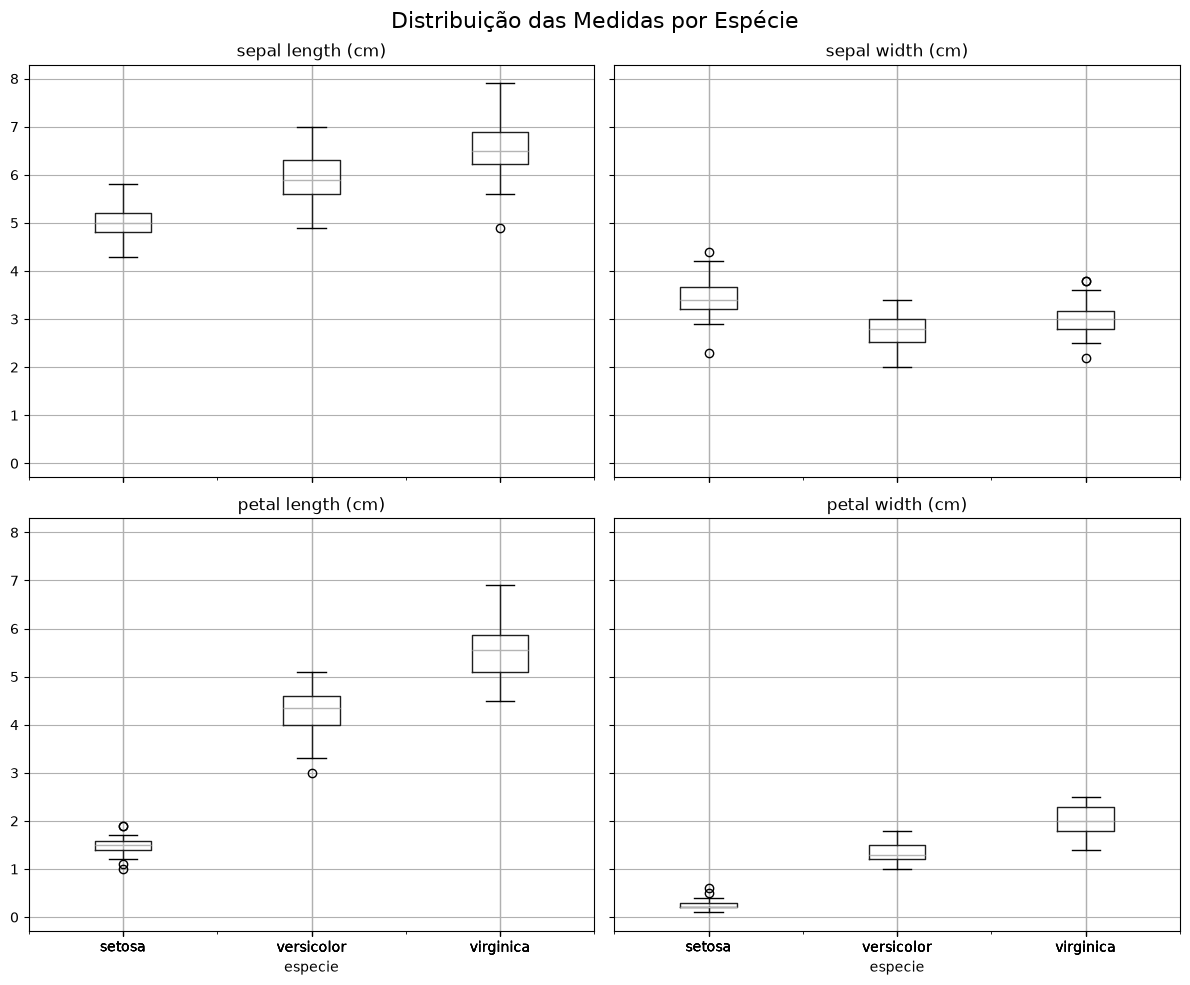

🔍 Observação: Note como a espécie 'setosa' é bem separada das outras!
   Isso significa que é mais fácil classificar a setosa do que versicolor vs virginica.


In [18]:
# Criar boxplots para cada medida, separados por espécie
df.boxplot(column=iris.feature_names, by='especie', figsize=(12, 10))
plt.suptitle('Distribuição das Medidas por Espécie', fontsize=16)
plt.tight_layout()
plt.show()

print("🔍 Observação: Note como a espécie 'setosa' é bem separada das outras!")
print("   Isso significa que é mais fácil classificar a setosa do que versicolor vs virginica.")

## Passo 5: Preparando os Dados para o Modelo

Antes de treinar o modelo, precisamos dividir os dados em dois conjuntos:

1. **Dados de TREINO** (80%): Usados para o modelo "aprender"
2. **Dados de TESTE** (20%): Usados para verificar se o modelo funciona bem com dados que nunca viu

```python
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
```

### Por que dividir os dados?
Imagine que um aluno estuda apenas com os exercícios da lista de exercícios. Se ele decora as respostas, vai tirar 100% na lista, mas pode não saber resolver questões novas.

Da mesma forma, queremos saber se o modelo **realmente aprendeu** os padrões ou apenas "decorou" os dados de treino. Por isso testamos com dados diferentes!

> 💡 O `random_state=42` garante que a divisão seja sempre a mesma (reprodutibilidade).

In [19]:
# Separar as features (X) e o target (y)
X = df[iris.feature_names]  # Medidas das flores
y = df['especie']  # Espécie da flor

# Dividir em treino (80%) e teste (20%)
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"📊 Dados de TREINO: {len(X_treino)} flores")
print(f"📊 Dados de TESTE: {len(X_teste)} flores")
print(f"\n📋 Treino - Distribuição:")
print(y_treino.value_counts())
print(f"\n📋 Teste - Distribuição:")
print(y_teste.value_counts())

📊 Dados de TREINO: 120 flores
📊 Dados de TESTE: 30 flores

📋 Treino - Distribuição:
especie
versicolor    41
setosa        40
virginica     39
Name: count, dtype: int64

📋 Teste - Distribuição:
especie
virginica     11
setosa        10
versicolor     9
Name: count, dtype: int64


## Passo 6: Treinando o Primeiro Modelo

Agora vamos treinar nosso primeiro modelo de regressão logística!

```python
modelo = LogisticRegression(max_iter=200)
modelo.fit(X_treino, y_treino)
```

### O que está acontecendo?
- `LogisticRegression()`: Cria um objeto do tipo "modelo de regressão logística"
- `fit()`: Treina o modelo com os dados de treino. O modelo "aprende" a relação entre as medidas e as espécies

> 💡 O `max_iter=200` é um limite máximo de iterações para o algoritmo de treino. Se o modelo não convergir, aumentamos esse número.

In [20]:
# Primeiro modelo: usar TODAS as 4 medidas
modelo1 = LogisticRegression(max_iter=200, random_state=42)
modelo1.fit(X_treino, y_treino)

print("✅ Modelo 1 treinado com sucesso!")
print(f"   Usando: {list(X_treino.columns)}")

✅ Modelo 1 treinado com sucesso!
   Usando: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


## Passo 7: Fazendo Previsões

Agora que o modelo está treinado, vamos usá-lo para prever as espécies!

```python
previsoes = modelo1.predict(X_teste)
```

### O que é `predict()`?
- `predict()`: Usa o modelo treinado para prever a espécie de cada flor no conjunto de teste
- O modelo olha as medidas e diz: "Acho que esta flor é da espécie X"

> 💡 Imagine que o modelo aprendeu uma "regra" durante o treino. Agora ele aplica essa regra nas flores novas (teste).

In [21]:
# Fazer previsões com o Modelo 1
previsoes1 = modelo1.predict(X_teste)

# Mostrar algumas previsões vs valores reais
resultados1 = pd.DataFrame({
    'Real': y_teste.values,
    'Previsto': previsoes1
})

print("🔮 Primeiras 15 previsões do Modelo 1:")
print(resultados1.head(15))

🔮 Primeiras 15 previsões do Modelo 1:
          Real    Previsto
0   versicolor  versicolor
1       setosa      setosa
2    virginica   virginica
3   versicolor  versicolor
4   versicolor  versicolor
5       setosa      setosa
6   versicolor  versicolor
7    virginica   virginica
8   versicolor  versicolor
9   versicolor  versicolor
10   virginica   virginica
11      setosa      setosa
12      setosa      setosa
13      setosa      setosa
14      setosa      setosa


## Passo 8: Calculando a Acurácia

Como sabemos se o modelo está bom? Calculamos a **acurácia**!

```python
acuracia = accuracy_score(y_teste, previsoes1)
```

### O que é acurácia?
Acurácia é a **porcentagem de previsões corretas**:

$$\text{Acurácia} = \frac{\text{Previsões Corretas}}{\text{Total de Previsões}} \times 100\%$$

> 💡 Se a acurácia é 90%, significa que o modelo acertou 90% das flores!

In [22]:
# Calcular acurácia do Modelo 1
acuracia1 = accuracy_score(y_teste, previsoes1)

print("=" * 50)
print("RESULTADO DO MODELO 1 (Todas as 4 medidas)")
print("=" * 50)
print(f"\n🎯 Acurácia: {acuracia1*100:.1f}%")
print(f"   O modelo acertou {acuracia1*len(y_teste):.0f} de {len(y_teste)} flores!")

if acuracia1 >= 0.95:
    print("\n🎉 Excelente! O modelo teve performance muito boa!")
elif acuracia1 >= 0.85:
    print("\n👍 Bom! O modelo teve performance satisfatória!")
else:
    print("\n📊 Acurácia moderada. Podemos tentar melhorar!")

RESULTADO DO MODELO 1 (Todas as 4 medidas)

🎯 Acurácia: 100.0%
   O modelo acertou 30 de 30 flores!

🎉 Excelente! O modelo teve performance muito boa!


## Passo 9: Comparando Dois Modelos

Agora vem a parte interessante! Vamos treinar **dois modelos diferentes** e comparar:

- **Modelo A**: Usa apenas o **comprimento da sépala** (uma única medida)
- **Modelo B**: Usa **todas as 4 medidas** (sépalas + pétalas)

### Por que comparar?
Queremos saber: uma única medida (comprimento da sépala) já é suficiente para classificar bem as flores? Ou precisamos de todas as medidas?

> 💡 Isso é muito comum na ciência de dados: testar diferentes combinações de variáveis para entender quais são mais importantes!

In [23]:
# Separar os dados de treino e teste
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Modelo A: Apenas comprimento da sépala
features_sepala = ['sepal length (cm)']
X_treino_sepala = X_treino[features_sepala]
X_teste_sepala = X_teste[features_sepala]

modelo_sepala = LogisticRegression(max_iter=200, random_state=42)
modelo_sepala.fit(X_treino_sepala, y_treino)
previsoes_sepala = modelo_sepala.predict(X_teste_sepala)
acuracia_sepala = accuracy_score(y_teste, previsoes_sepala)

# Modelo B: Todas as medidas
modelo_todas = LogisticRegression(max_iter=200, random_state=42)
modelo_todas.fit(X_treino, y_treino)
previsoes_todas = modelo_todas.predict(X_teste)
acuracia_todas = accuracy_score(y_teste, previsoes_todas)

print("=" * 60)
print("COMPARAÇÃO DOS MODELOS")
print("=" * 60)
print(f"\n🌿 Modelo A (apenas comprimento da sépala): {acuracia_sepala*100:.1f}%")
print(f"🌸 Modelo B (todas as medidas): {acuracia_todas*100:.1f}%")
print(f"\n📊 Diferença: {(acuracia_todas - acuracia_sepala)*100:+.1f} pontos percentuais")

COMPARAÇÃO DOS MODELOS

🌿 Modelo A (apenas comprimento da sépala): 83.3%
🌸 Modelo B (todas as medidas): 100.0%

📊 Diferença: +16.7 pontos percentuais


## Passo 10: Visualizando a Comparação

Vamos criar um gráfico para comparar visualmente a acurácia dos dois modelos!

```python
plt.bar(['Modelo A\n(Apenas Comp. Sépala)', 'Modelo B\n(Todas as Medidas)'], 
        [acuracia_sepala*100, acuracia_todas*100])
```

### O que é um gráfico de barras?
Um gráfico de barras é uma forma visual de comparar quantidades. Cada barra representa um valor, e podemos ver facilmente qual é maior ou menor.

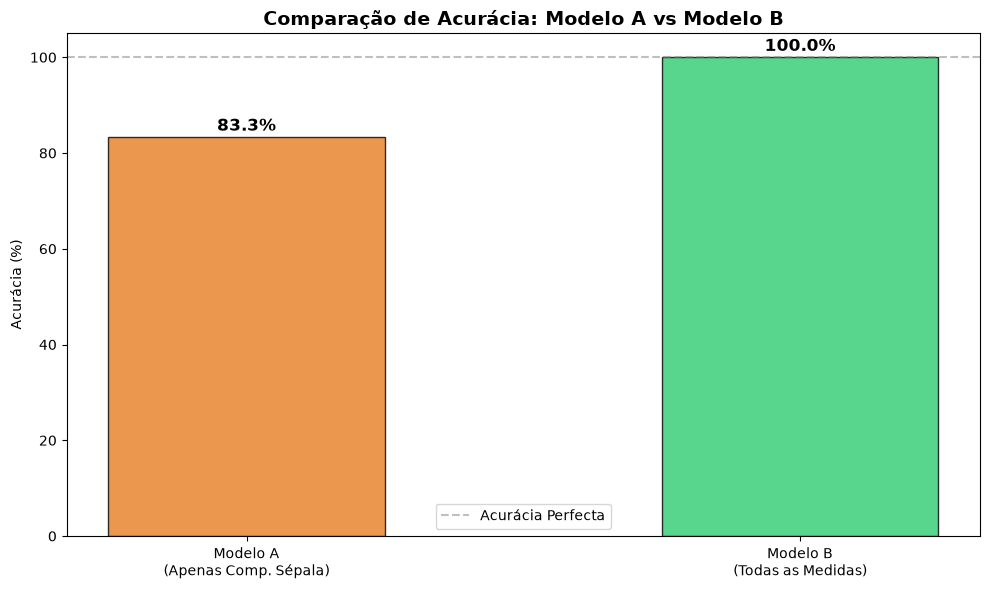

In [24]:
# Criar gráfico de barras comparando os modelos
modelos = ['Modelo A\n(Apenas Comp. Sépala)', 'Modelo B\n(Todas as Medidas)']
acuracias = [acuracia_sepala * 100, acuracia_todas * 100]
cores = ['#e67e22', '#2ecc71']

plt.figure(figsize=(10, 6))
barras = plt.bar(modelos, acuracias, color=cores, alpha=0.8, edgecolor='black', width=0.5)

# Adicionar valores em cima das barras
for barra, valor in zip(barras, acuracias):
    plt.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 0.5,
             f'{valor:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.ylim(0, 105)
plt.ylabel('Acurácia (%)')
plt.title('Comparação de Acurácia: Modelo A vs Modelo B', fontsize=14, fontweight='bold')
plt.axhline(y=100, color='gray', linestyle='--', alpha=0.5, label='Acurácia Perfecta')
plt.legend()
plt.tight_layout()
plt.show()

## Passo 11: Discussão dos Resultados

Agora vamos analisar o que aprendemos!

### O que observamos?

1. **O Modelo A (apenas comprimento da sépala)** tem uma acurácia moderada
   - Uma única medida já consegue classificar parte das flores corretamente
   - A espécie "setosa" tem sépalas significativamente maiores que as outras duas
   - Porém, versicolor e virginica se sobrepõem bastante no comprimento da sépala

2. **O Modelo B (todas as medidas)** tem acurácia muito superior
   - Com mais informações, o modelo consegue distinguir melhor as espécies
   - As pétalas são especialmente úteis para separar versicolor de virginica
   - A combinação de todas as medidas captura padrões mais completos

### Por que a diferença é tão grande?

| Aspecto | Modelo A (1 medida) | Modelo B (4 medidas) |
|---|---|---|
| **Informação** | Limitada | Completa |
| **Separação Setosa** | Boa (sépalas grandes) | Excelente |
| **Separação Versicolor vs Virginica** | Difícil (sobreposição) | Boa (pétalas ajudam muito) |
| **Risco de erro** | Alto | Baixo |

> 💡 **Lição importante**: Na ciência de dados, mais informações (features relevantes) geralmente levam a melhores previsões. Mas também precisamos cuidado com "excesso de informação" — features irrelevantes podem atrapalhar!

### Conceitos Estatísticos Aprendidos

| Conceito | Explicação |
|---|---|
| **Regressão Logística** | Algoritmo de classificação que prevê categorias |
| **Acurácia** | Porcentagem de previsões corretas |
| **Treino/Teste** | Dividir dados para avaliar se o modelo generaliza |
| **Features** | Variáveis de entrada (medidas das flores) |
| **Target** | Variável de saída (espécie da flor) |
| **Overfitting** | Quando o modelo decora os dados de treino e não generaliza |

> 💡 Na prática, cientistas de dados testam vários modelos e várias combinações de features para encontrar a melhor solução!

## Passo 12: Acurácia de 100% — Memorização ou Aprendizado Real?

Mas acurácia de 100% não seria indesejado? O modelo não estaria 'memorizando' o dataset?

**Neste caso, 100% de acurácia NÃO é memorização.** Veja por quê:

### Por que NÃO é memorização (overfitting)?

| Situação | O que acontece | É problema? |
|---|---|---|
| **Overfitting** | Modelo decora os dados de TREINO e falha nos dados de TESTE | ✅ Sim, é problema |
| **Bom aprendizado** | Modelo aprende padrões reais e acerta treino E teste | ❌ Não é problema |

No nosso notebook, **não estamos testando no mesmo dados que treinamos**:

```
150 flores
├── 120 flores → TREINO (modelo aprende aqui)
└── 30 flores  → TESTE  (modelo nunca viu antes!)
```

Se o modelo acerta 100% nas 30 flores de **teste** (que ele nunca viu), isso significa que ele **realmente aprendeu os padrões**, não que decorou!

### Quando 100% seria preocupante?

⚠️ **Sinais de possível memorização (overfitting):**

1. **Acurácia de treino = 100%, mas acurácia de teste baixa**
   - Ex: Treino 99%, Teste 60% → Modelo decorou!

2. **Dataset muito pequeno**
   - Se tivermos apenas 10 flores e acertarmos 10/10, pode ser sorte

3. **Features "vazadas" (data leakage)**
   - Se uma feature contém informação direta da resposta

### Por que o Iris é especial?

O dataset Iris é **bem separado** — as espécies têm características distintas o suficiente para que um modelo simples consiga classificar corretamente. Isso é **desejável**, não um problema!

> 💡 **Regra prática**: Se a acurácia de treino e de teste são semelhantes (ambas altas ou ambas baixas), o modelo está generalizando bem. Se a de treino é muito maior que a de teste, pode haver overfitting.